<a href="https://colab.research.google.com/github/Mahesh527784/DataAnalyst/blob/main/DataAnalyst%5B28_04_2025%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd

# Load the Universities data
universities = pd.read_csv('/content/Universities.csv')

# Check the first few rows
print(universities.head())

# Drop records with missing values
universities_clean = universities.dropna()

# Show shapes
print(f"Original shape: {universities.shape}")
print(f"After dropping missing values: {universities_clean.shape}")


                        College Name State  Public (1)/ Private (2)  \
0          Alaska Pacific University    AK                        2   
1  University of Alaska at Fairbanks    AK                        1   
2     University of Alaska Southeast    AK                        1   
3  University of Alaska at Anchorage    AK                        1   
4        Alabama Agri. & Mech. Univ.    AL                        1   

   # appli. rec'd  # appl. accepted  # new stud. enrolled  \
0           193.0             146.0                  55.0   
1          1852.0            1427.0                 928.0   
2           146.0             117.0                  89.0   
3          2065.0            1598.0                1162.0   
4          2817.0            1920.0                 984.0   

   % new stud. from top 10%  % new stud. from top 25%  # FT undergrad  \
0                      16.0                      44.0           249.0   
1                       NaN                       NaN       

In [35]:
from sklearn.preprocessing import StandardScaler

# Select continuous columns (excluding 'State', 'Private/Public', 'Name')
continuous_cols = [col for col in universities_clean.columns if universities_clean[col].dtype in ['float64', 'int64']]
continuous_cols = [col for col in continuous_cols if col not in ['State', 'Private/Public', 'Name']]

# Standardize
scaler = StandardScaler()
universities_scaled = scaler.fit_transform(universities_clean[continuous_cols])


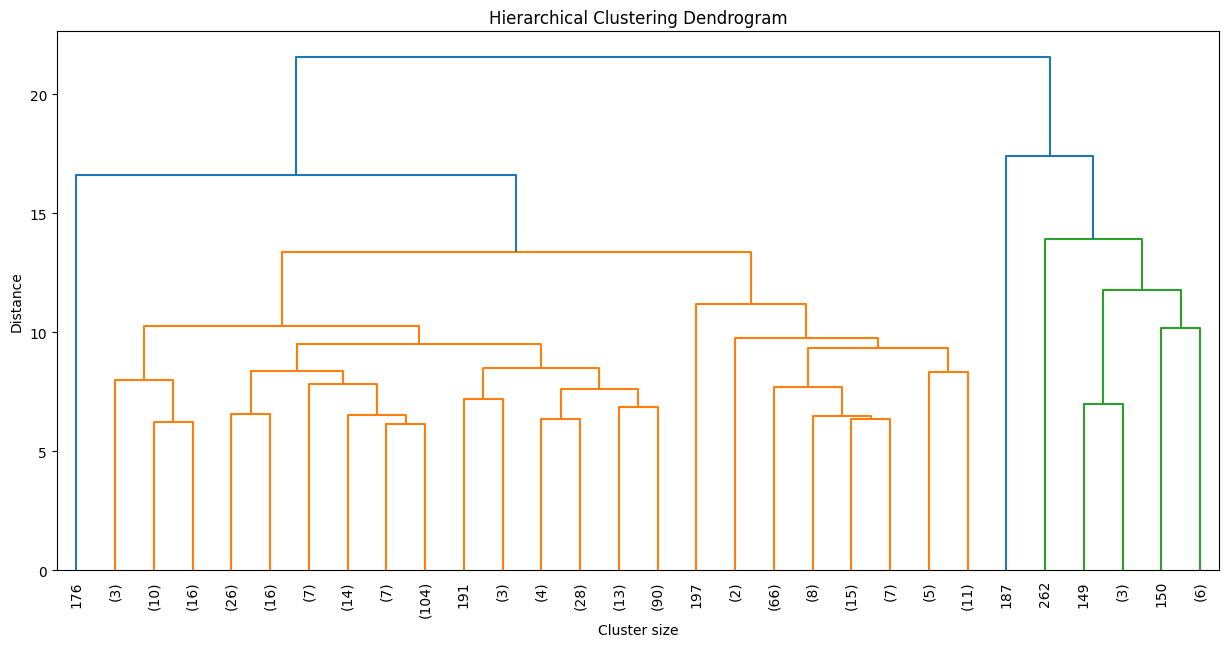

In [36]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Linkage matrix
linkage_matrix = linkage(universities_scaled, method='complete', metric='euclidean')

# Dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()


In [37]:
from scipy.cluster.hierarchy import fcluster

# Assign clusters
clusters = fcluster(linkage_matrix, 4, criterion='maxclust')
universities_clean['Cluster'] = clusters

# Summary statistics
summary = universities_clean.groupby('Cluster')[continuous_cols].mean()
print(summary)


         Public (1)/ Private (2)  # appli. rec'd  # appl. accepted  \
Cluster                                                              
1                       1.739606     2752.124726       1793.078775   
2                       2.000000      601.000000        396.000000   
3                       1.333333    17750.333333      12118.500000   
4                       1.000000    11054.000000       6397.000000   

         # new stud. enrolled  % new stud. from top 10%  \
Cluster                                                   
1                  684.503282                 27.868709   
2                  203.000000                  1.000000   
3                 4263.916667                 35.916667   
4                 3524.000000                 26.000000   

         % new stud. from top 25%  # FT undergrad  # PT undergrad  \
Cluster                                                             
1                       55.347921     3084.415755      684.842451   
2                

<ipython-input-37-c67e930b5db5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  universities_clean['Cluster'] = clusters


In [38]:
from scipy.cluster.hierarchy import fcluster

# Assign clusters
clusters = fcluster(linkage_matrix, 4, criterion='maxclust')
universities_clean['Cluster'] = clusters

# Summary statistics
summary = universities_clean.groupby('Cluster')[continuous_cols].mean()
print(summary)


         Public (1)/ Private (2)  # appli. rec'd  # appl. accepted  \
Cluster                                                              
1                       1.739606     2752.124726       1793.078775   
2                       2.000000      601.000000        396.000000   
3                       1.333333    17750.333333      12118.500000   
4                       1.000000    11054.000000       6397.000000   

         # new stud. enrolled  % new stud. from top 10%  \
Cluster                                                   
1                  684.503282                 27.868709   
2                  203.000000                  1.000000   
3                 4263.916667                 35.916667   
4                 3524.000000                 26.000000   

         % new stud. from top 25%  # FT undergrad  # PT undergrad  \
Cluster                                                             
1                       55.347921     3084.415755      684.842451   
2                

<ipython-input-38-c67e930b5db5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  universities_clean['Cluster'] = clusters


In [43]:
# Cross-tab for Private/Public
private_cross = pd.crosstab(universities_clean['Cluster'], universities_clean['Public (1)/ Private (2)'])
print(private_cross)

# Cross-tab for State (optional)
state_cross = pd.crosstab(universities_clean['Cluster'], universities_clean['State'])
print(state_cross)


Public (1)/ Private (2)    1    2
Cluster                          
1                        119  338
2                          0    1
3                          8    4
4                          1    0
State    AK  AL  AR  AZ  CA  CO  CT  DC  DE  FL  ...  SD  TN  TX  UT  VA  VT  \
Cluster                                          ...                           
1         2   4   4   1  14   6  10   4   2   8  ...   4  15  18   2  15   7   
2         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   
3         0   0   0   1   1   0   0   0   0   0  ...   0   0   2   0   0   0   
4         0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   

State    WA  WI  WV  WY  
Cluster                  
1         2   9   2   1  
2         0   0   0   0  
3         0   0   0   0  
4         0   0   0   0  

[4 rows x 50 columns]


In [46]:
# Locate Tufts University
tufts = universities[universities['College Name'] == 'Tufts University']

# Drop NA columns for Tufts
tufts_values = tufts[continuous_cols].dropna(axis=1)

# Find cluster means
cluster_means = universities_clean.groupby('Cluster')[continuous_cols].mean()

# Calculate Euclidean distance
import numpy as np
distances = []

for cluster in cluster_means.index:
    common_cols = tufts_values.columns
    cluster_point = cluster_means.loc[cluster, common_cols]
    tufts_point = tufts_values.iloc[0]
    distance = np.linalg.norm(cluster_point - tufts_point)
    distances.append((cluster, distance))

# Closest cluster
closest_cluster = min(distances, key=lambda x: x[1])[0]
print(f"Tufts University is closest to Cluster {closest_cluster}")

# Impute missing values
imputed_values = cluster_means.loc[closest_cluster]
print(imputed_values)


Tufts University is closest to Cluster 1
Public (1)/ Private (2)         1.739606
# appli. rec'd               2752.124726
# appl. accepted             1793.078775
# new stud. enrolled          684.503282
% new stud. from top 10%       27.868709
% new stud. from top 25%       55.347921
# FT undergrad               3084.415755
# PT undergrad                684.842451
in-state tuition             9476.470460
out-of-state tuition        10577.700219
room                         2210.625821
board                        2112.424508
add. fees                     370.196937
estim. book costs             543.844639
estim. personal $            1295.908096
% fac. w/PHD                   73.004376
stud./fac. ratio               13.920788
Graduation rate                65.628009
Name: 1, dtype: float64


***SECOND PART***

In [47]:
toyota = pd.read_csv('/content/ToyotaCorolla.csv')
print(toyota.head())


   Id                                          Model  Price  Age (month)  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500           23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750           23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950           24   
3   4  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950           26   
4   5    TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750           30   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color  ... Powered_Windows  \
0         10      2002  46986    Diesel  90          1  ...               1   
1         10      2002  72937    Diesel  90          1  ...               0   
2          9      2002  41711    Diesel  90          1  ...               0   
3          7      2002  48000    Diesel  90          0  ...               0   
4          3      2002  38500    Diesel  90          0  ...               1   

   Power_Steering  Radio  Mistlamps  Sport_Model  Backseat_Divider  

In [48]:
# Categorical columns
categorical_cols = toyota.select_dtypes(include=['object']).columns
print(categorical_cols)


Index(['Model', 'Fuel_Type', 'Color'], dtype='object')


In [49]:
# Create dummy variables
toyota_dummies = pd.get_dummies(toyota, columns=categorical_cols, drop_first=True)
print(toyota_dummies.head())


   Id  Price  Age (month)  Mfg_Month  Mfg_Year     KM  HP  Met_Color  \
0   1  13500           23         10      2002  46986  90          1   
1   2  13750           23         10      2002  72937  90          1   
2   3  13950           24          9      2002  41711  90          1   
3   4  14950           26          7      2002  48000  90          0   
4   5  13750           30          3      2002  38500  90          0   

   Automatic    CC  ...  Fuel_Type_Petrol  Color_Black  Color_Blue  \
0          0  2000  ...             False        False        True   
1          0  2000  ...             False        False       False   
2          0  2000  ...             False        False        True   
3          0  2000  ...             False         True       False   
4          0  2000  ...             False         True       False   

   Color_Green  Color_Grey  Color_Red  Color_Silver  Color_Violet  \
0        False       False      False         False         False   
1       

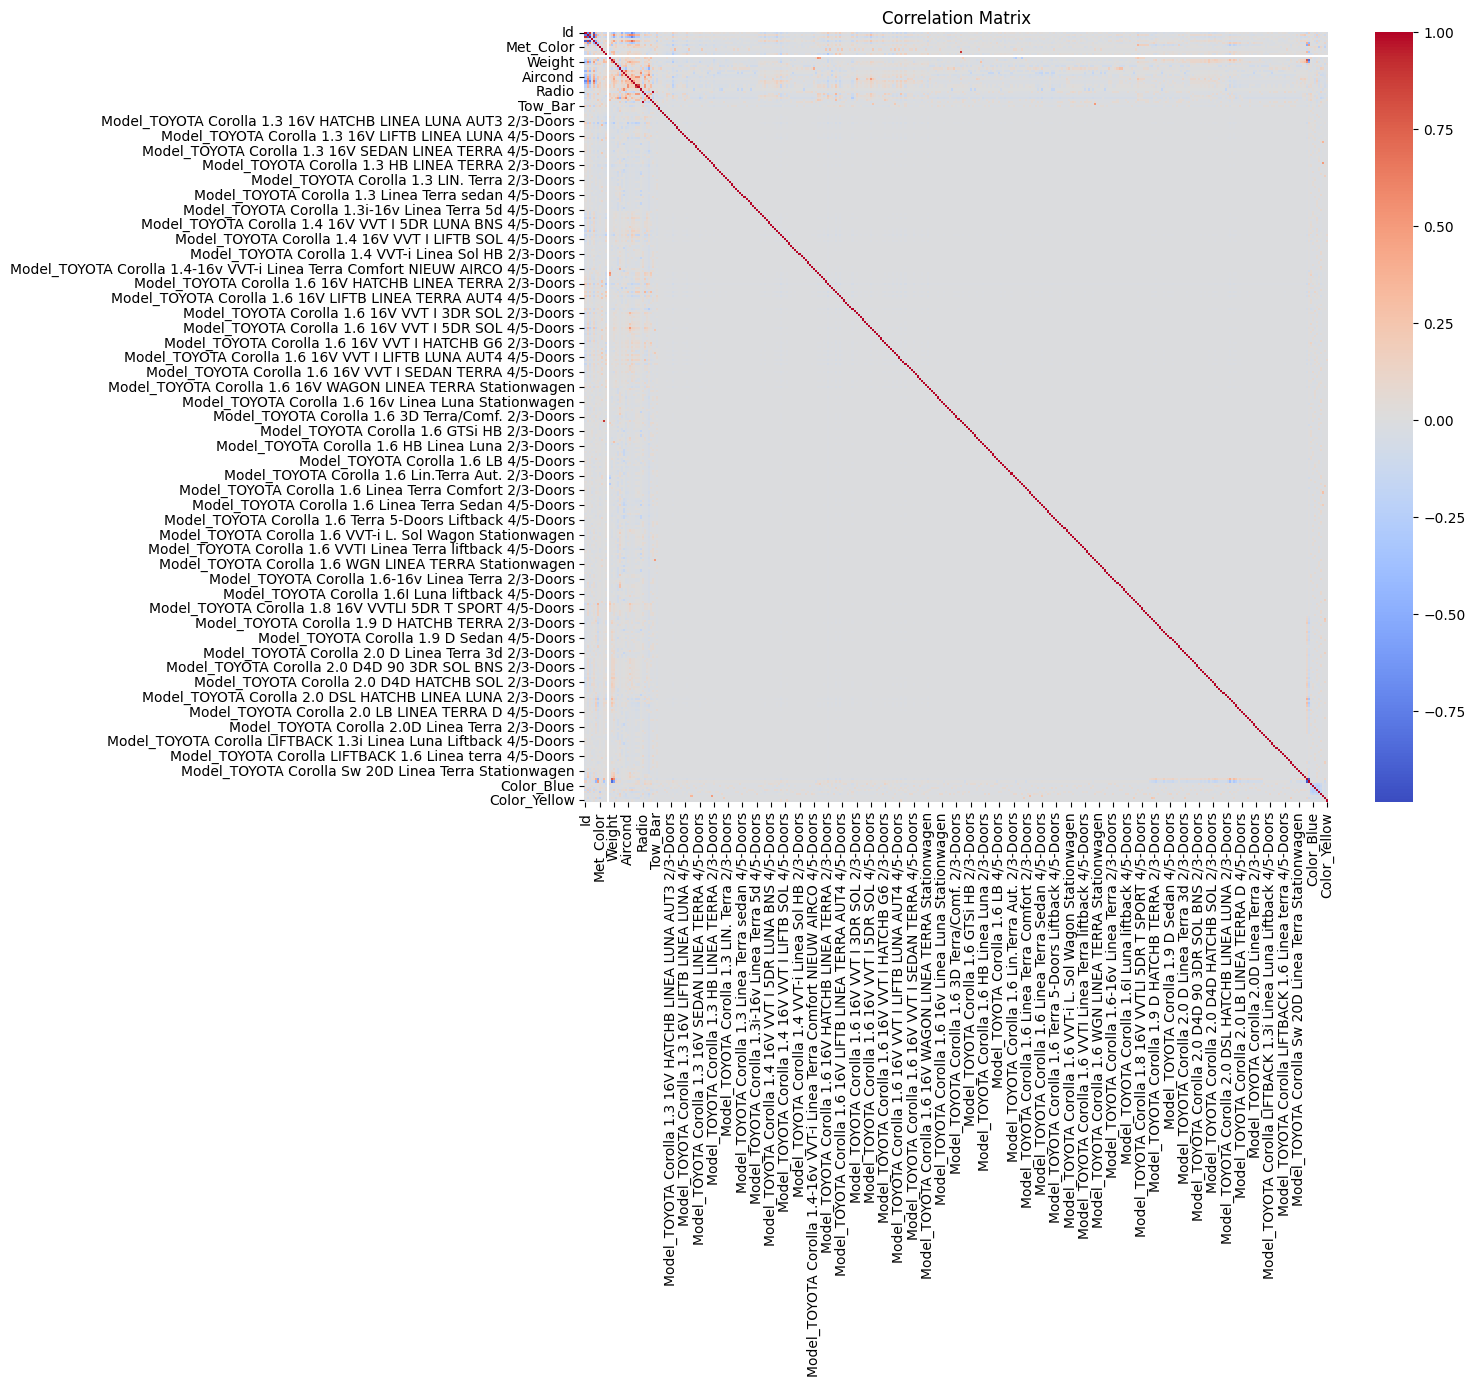

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = toyota_dummies.corr()

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


**Part3**

In [51]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Step 1: Define the points
points = {
    'a': np.array([0, 0]),
    'b': np.array([8, 0]),
    'c': np.array([16, 0]),
    'd': np.array([0, 6]),
    'e': np.array([8, 6]),
    'f': np.array([16, 6])
}

labels = list(points.keys())
coords = np.array(list(points.values()))

# Step 2: Randomly choose 3 starting centroids
random.seed(42)  # For reproducibility
initial_centroids_idx = random.sample(range(6), 3)
centroids = coords[initial_centroids_idx]
print(f"Initial centroids chosen (points {np.array(labels)[initial_centroids_idx]}):\n{centroids}\n")

# Helper function: Assign points to nearest centroid
def assign_clusters(coords, centroids):
    clusters = {}
    for idx, point in enumerate(coords):
        distances = np.linalg.norm(point - centroids, axis=1)
        min_idx = np.argmin(distances)
        clusters.setdefault(min_idx, []).append(idx)
    return clusters

# Helper function: Update centroids
def update_centroids(coords, clusters):
    new_centroids = []
    for cluster_points in clusters.values():
        cluster_coords = coords[cluster_points]
        centroid = np.mean(cluster_coords, axis=0)
        new_centroids.append(centroid)
    return np.array(new_centroids)

# Step 3: Iterate
max_iters = 10
iteration = 0
prev_clusters = None

while iteration < max_iters:
    print(f"Iteration {iteration + 1}:")

    # Assign clusters
    clusters = assign_clusters(coords, centroids)

    # Print current cluster assignments
    for cluster_id, point_indices in clusters.items():
        cluster_points = [labels[i] for i in point_indices]
        print(f"  Cluster {cluster_id + 1}: {cluster_points}")

    # Check if clusters have stabilized
    if clusters == prev_clusters:
        print("\nClusters stabilized! Convergence achieved.")
        break

    # Update centroids
    centroids = update_centroids(coords, clusters)

    # Save previous clusters
    prev_clusters = clusters.copy()

    iteration += 1
    print()

print(f"\nTotal iterations to converge: {iteration}")


Initial centroids chosen (points ['f' 'a' 'e']):
[[16  6]
 [ 0  0]
 [ 8  6]]

Iteration 1:
  Cluster 2: ['a', 'd']
  Cluster 3: ['b', 'e']
  Cluster 1: ['c', 'f']

Iteration 2:
  Cluster 1: ['a', 'd']
  Cluster 2: ['b', 'e']
  Cluster 3: ['c', 'f']

Iteration 3:
  Cluster 1: ['a', 'd']
  Cluster 2: ['b', 'e']
  Cluster 3: ['c', 'f']

Clusters stabilized! Convergence achieved.

Total iterations to converge: 2
